In [2]:
import os
from platform import system

from dotenv import load_dotenv
from langchain_core.messages.system import SystemMessage
from langchain_groq import ChatGroq

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#custom tools
def add(a: int, b: int) -> int:
    """
    add two numbers a and b, and return the result
    Args:
        a (int): first number
        b (int): second number
    """
    return a + b


def multiply(a: int, b: int) -> int:
    """
    multiply two numbers a and b, and return the result
    Args: a (int): first number
        b (int): second number
    """
    return a * b


def divide(a: int, b: int) -> int:
    """
    divide two numbers a and b, and return the result
    Args: a (int): first number
        b (int): second number
    """
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b


tools = [add, multiply, divide]

In [4]:
#binding the tools with the LLM
llm_with_tools = llm.bind_tools(tools=tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C526444440>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C526444EC0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'add two numbers a and b, and return the result\nArgs:\n    a (int): first number\n    b (int): second number', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'multiply two numbers a and b, and return the result\nAr

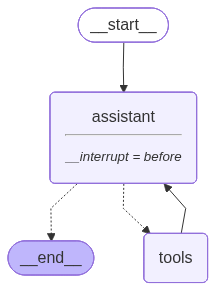

In [5]:
#workflow with langGraph
from IPython.display import Image, display
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph.message import MessagesState
from langgraph.prebuilt.tool_node import ToolNode

#system message
system_msg = SystemMessage(
    content="You are a helpful assistant that can perform basic math operations like addition, multiplication and division. You have access to the following tools: add, multiply, divide. When you receive a user query, determine which tool is best suited to answer the query and use that tool to get the answer.")


#Nodes
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"] + [system_msg])]}


#graph construction

builder = StateGraph(MessagesState)

#define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
#edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant",
                              tools_condition
                            )
builder.add_edge("tools","assistant")
memory = MemorySaver()

#while compiling graph we need to add interrupt_before to make sure that the graph interrupts before calling the assistant node and saves the state in memory. This allows us to have a human in the loop and check the state of the graph before the assistant node is called.
compiled_graph = builder.compile(interrupt_before=["assistant"],checkpointer=memory)

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [6]:
thread = {"configurable":{"thread_id":"1234"}}
initial_input = {"messages":[HumanMessage(content="what is 2+2?")]}

for event in compiled_graph.stream(initial_input, config=thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what is 2+2?


In [7]:
state = compiled_graph.get_state(thread)
state.next

('assistant',)

In [8]:
state

StateSnapshot(values={'messages': [HumanMessage(content='what is 2+2?', additional_kwargs={}, response_metadata={}, id='76883a27-a90d-4c4d-be2c-0d4a6d9fb302')]}, next=('assistant',), config={'configurable': {'thread_id': '1234', 'checkpoint_ns': '', 'checkpoint_id': '1f129e7e-5d90-686d-8000-58255c4303bc'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-27T14:18:59.558568+00:00', parent_config={'configurable': {'thread_id': '1234', 'checkpoint_ns': '', 'checkpoint_id': '1f129e7e-5d86-66f6-bfff-ab50b44efcb1'}}, tasks=(PregelTask(id='35ed11c3-f2a8-0d11-4e0f-eb132e3e498a', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [9]:
for event in compiled_graph.stream(None, config=thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what is 2+2?
================================== Ai Message ==================================
Tool Calls:
  add (fc_9e14ae2e-c1ae-4975-be0c-626c33dfe291)
 Call ID: fc_9e14ae2e-c1ae-4975-be0c-626c33dfe291
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


### EDITING THE STATE IN THE MIDDLE OF THE WORKFLOW

In [10]:
initial_input = {"messages":HumanMessage(content="what is 2*2?")}
thread = {"configurable":{"thread_id":"1234"}}
for event in compiled_graph.stream(initial_input, config=thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what is 2*2?


In [11]:
state = compiled_graph.get_state(thread)
state.next

('assistant',)

In [12]:
compiled_graph.update_state(thread,{"messages":[HumanMessage(content="what is 4*2?")]})


{'configurable': {'thread_id': '1234',
  'checkpoint_ns': '',
  'checkpoint_id': '1f129e7e-636e-6c7a-8005-ce0dd350550d'}}

In [13]:
new_state = compiled_graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2+2?
================================== Ai Message ==================================
Tool Calls:
  add (fc_9e14ae2e-c1ae-4975-be0c-626c33dfe291)
 Call ID: fc_9e14ae2e-c1ae-4975-be0c-626c33dfe291
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================ Human Message =================================

what is 2*2?
================================ Human Message =================================

what is 4*2?


In [14]:
for event in compiled_graph.stream(None, config=thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what is 4*2?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_31b94b02-8d61-43b0-a56b-0d23b3637798)
 Call ID: fc_31b94b02-8d61-43b0-a56b-0d23b3637798
  Args:
    a: 4
    b: 2
================================= Tool Message =================================
Name: multiply

8


### Workflow will Wait for the User Input

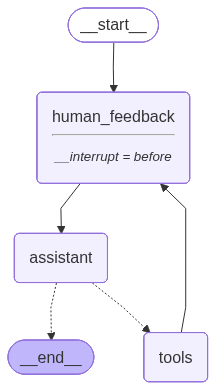

In [15]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


## Human feedback node

def human_feedback(state:MessagesState):
    pass

### Assistant node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

## Graph

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)


## Define the edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

## get user input

user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

2 + 3

================================== Ai Message ==================================
Tool Calls:
  multiply (fc_a4f0bc1a-0500-417f-b10f-970981256b62)
 Call ID: fc_a4f0bc1a-0500-417f-b10f-970981256b62
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [17]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()


================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

5
